## 1.1 Needed Packages

In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Importing pakages

#Data Processing
import numpy as np
import pandas as pd
import math

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Data processing modules
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Machine Learing Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


## 1.2 Data Loading

In [3]:
data = 'ESS.csv'
df = pd.read_csv(data)
df_clean = df.drop(['name','essround','edition','proddate','idno','dweight','anweight','prob', 'stratum','psu','pspwght','pweight'], axis=1)
# Define missing value codes for each variable
missing_map = {
    'bctprd': [7, 8, 9],
    'gndr': [9],
    'agea': [999],
    'eduyrs': [77, 88, 99],
    'netusoft': [7,8,9],
    'nwspol': [7777,8888,9999]
}

# Variables with 66, 77, 88, 99 as missing
value_vars = ['ipcrtiva', 'impricha', 'ipeqopta', 'ipshabta', 'impsafea', 'impdiffa',
              'ipfrulea', 'ipudrsta', 'ipmodsta', 'ipgdtima', 'impfreea', 'iphlppla',
              'ipsucesa', 'ipstrgva', 'ipadvnta', 'ipbhprpa', 'iprspota', 'iplylfra',
              'impenva', 'imptrada', 'impfuna']

for var in value_vars:
    missing_map[var] = [66, 77, 88, 99]

# Replace defined missing codes with NaN
for col, codes in missing_map.items():
    df_clean[col] = df_clean[col].replace(codes, np.nan)

df_clean.rename(columns={'agea': 'age', 'nwspol':'news', 'eduyrs': 'education_years', 'gndr': 'gender', 'cntry':'country', 'bctprd':'boycott', 'netusoft': 'internet'}, inplace=True)

df_clean['boycott'] = df_clean['boycott'].replace(2, 0)
df_clean = df_clean.dropna(subset=['boycott'])


## 1.3 EDA

In [4]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 49806 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          49806 non-null  str    
 1   news             49090 non-null  float64
 2   internet         49756 non-null  float64
 3   boycott          49806 non-null  float64
 4   gender           49806 non-null  int64  
 5   age              49429 non-null  float64
 6   education_years  48943 non-null  float64
 7   ipcrtiva         48898 non-null  float64
 8   impricha         48991 non-null  float64
 9   ipeqopta         48945 non-null  float64
 10  ipshabta         48918 non-null  float64
 11  impsafea         49032 non-null  float64
 12  impdiffa         48959 non-null  float64
 13  ipfrulea         48625 non-null  float64
 14  ipudrsta         48845 non-null  float64
 15  ipmodsta         48919 non-null  float64
 16  ipgdtima         48965 non-null  float64
 17  impfreea         48995 non-n

In [5]:
df_clean.describe()

,news,internet,boycott,gender,age,education_years,ipcrtiva,impricha,ipeqopta,ipshabta,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
count,49090.000000,49756.000000,49806.000000,49806.000000,49429.000000,48943.000000,48898.000000,48991.000000,48945.000000,48918.000000,...,49017.000000,48847.000000,48651.000000,48929.000000,48857.000000,48778.000000,48994.000000,48983.000000,48967.000000,48953.000000
mean,97.757547,4.199875,0.185259,1.539112,51.606425,13.248554,2.621089,4.071360,2.048258,3.225255,...,2.192872,3.164903,2.242667,3.813730,2.635405,3.166756,1.970935,2.173264,2.709274,2.959962
std,159.101565,1.418989,0.388511,0.498473,18.665848,4.016341,1.290143,1.360125,1.075486,1.411399,...,1.021043,1.377196,1.166905,1.455888,1.249533,1.387369,0.978976,1.059117,1.364465,1.332657
min,0.000000,1.000000,0.000000,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,30.000000,4.000000,0.000000,1.000000,37.000000,11.000000,2.000000,3.000000,1.000000,2.000000,...,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000
50%,60.000000,5.000000,0.000000,2.000000,52.000000,13.000000,2.000000,4.000000,2.000000,3.000000,...,2.000000,3.000000,2.000000,4.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000
75%,120.000000,5.000000,0.000000,2.000000,67.000000,16.000000,3.000000,5.000000,3.000000,4.000000,...,3.000000,4.000000,3.000000,5.000000,3.000000,4.000000,2.000000,3.000000,4.000000,4.000000
max,1440.000000,5.000000,1.000000,2.000000,90.000000,69.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000


In [6]:
df_clean.head(5)

,country,news,internet,boycott,gender,age,education_years,ipcrtiva,impricha,ipeqopta,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
0,AT,90.0,5.0,0.0,1,65.0,12.0,3.0,5.0,2.0,...,2.0,3.0,2.0,5.0,2.0,2.0,2.0,2.0,3.0,3.0
1,AT,90.0,5.0,1.0,2,21.0,14.0,2.0,4.0,2.0,...,1.0,4.0,2.0,4.0,2.0,4.0,1.0,1.0,4.0,2.0
2,AT,30.0,5.0,1.0,2,53.0,16.0,1.0,4.0,1.0,...,1.0,3.0,2.0,4.0,3.0,3.0,1.0,1.0,3.0,2.0
3,AT,15.0,1.0,0.0,2,78.0,14.0,3.0,4.0,2.0,...,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,3.0
4,AT,60.0,5.0,0.0,1,64.0,12.0,3.0,4.0,2.0,...,2.0,2.0,2.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0


In [7]:

df_clean[['gender', 'boycott']] = df_clean[['gender', 'boycott']].astype('object')
numerical_cols = df_clean.select_dtypes(include = 'float64').columns
categorical_cols = df_clean.select_dtypes(include = 'object').columns

print(numerical_cols.values)
print(categorical_cols.values)



<StringArray>
[           'news',        'internet',             'age', 'education_years',
        'ipcrtiva',        'impricha',        'ipeqopta',        'ipshabta',
        'impsafea',        'impdiffa',        'ipfrulea',        'ipudrsta',
        'ipmodsta',        'ipgdtima',        'impfreea',        'iphlppla',
        'ipsucesa',        'ipstrgva',        'ipadvnta',        'ipbhprpa',
        'iprspota',        'iplylfra',         'impenva',        'imptrada',
         'impfuna']
Length: 25, dtype: str
<StringArray>
['country', 'boycott', 'gender']
Length: 3, dtype: str


/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_58842/284300885.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include = 'object').columns


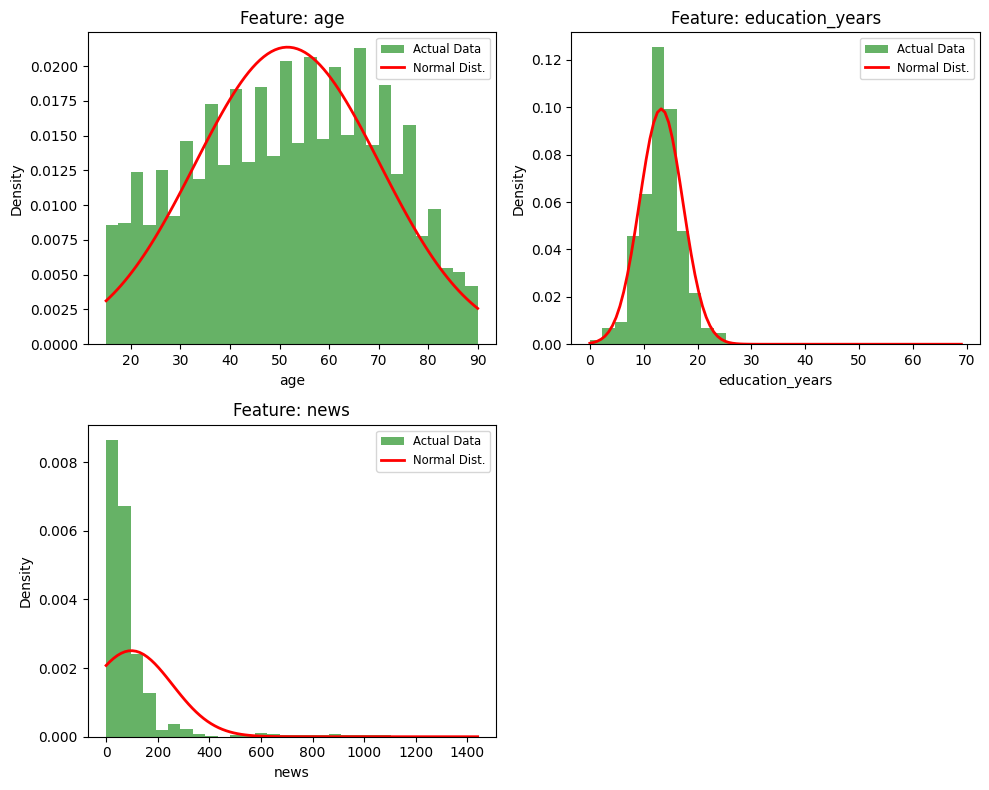

In [8]:

# 1. Define  features 
selected_cols = ['age', 'education_years', 'news'] 
# If you want to run all numerical columns, use: selected_cols = numerical_cols
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

# 2. Calculate dynamic grid dimensions
n_features = len(selected_cols)
n_cols = 2  # You can change this to 3 or 4 for more columns
n_rows = math.ceil(n_features / n_cols)

# 3. Initialize the figure
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))

# Ensure ax is an array even if there is only 1 plot
if n_features > 1:
    ax = ax.flatten()
else:
    ax = [ax]

# 4. Loop through each feature to create the plots
for c, column in enumerate(selected_cols):
    # Calculate mean (mu) and standard deviation (sigma)
    mu, sigma = X[column].mean(), X[column].std()
    
    # Plot Histogram: density=True normalizes the y-axis to total 1 (Density)
    # Using 20-30 bins is standard for seeing the distribution shape
    count, bins_edges, ignored = ax[c].hist(X[column], bins=30, density=True, 
                                            alpha=0.6, color='g', label='Actual Data')

    # Generate smooth X-values for the Normal Distribution curve
    # This prevents the "jagged" red line seen when using histogram bins
    x_smooth = np.linspace(X[column].min(), X[column].max(), 100)
    
    # Calculate the Probability Density Function (PDF)
    pdf = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x_smooth - mu) ** 2 / (2 * sigma ** 2))
    
    # Plot the Normal Distribution curve
    ax[c].plot(x_smooth, pdf, linewidth=2, color='r', label='Normal Dist.')

    # Formatting
    ax[c].set_title(f'Feature: {column}')
    ax[c].set_xlabel(column)
    ax[c].set_ylabel('Density')
    ax[c].legend(fontsize='small')

# 5. Hide unused axes (if n_features < total grid slots)
for i in range(n_features, len(ax)):
    ax[i].axis('off')

# 6. Final layout and save
plt.tight_layout()
plt.show()

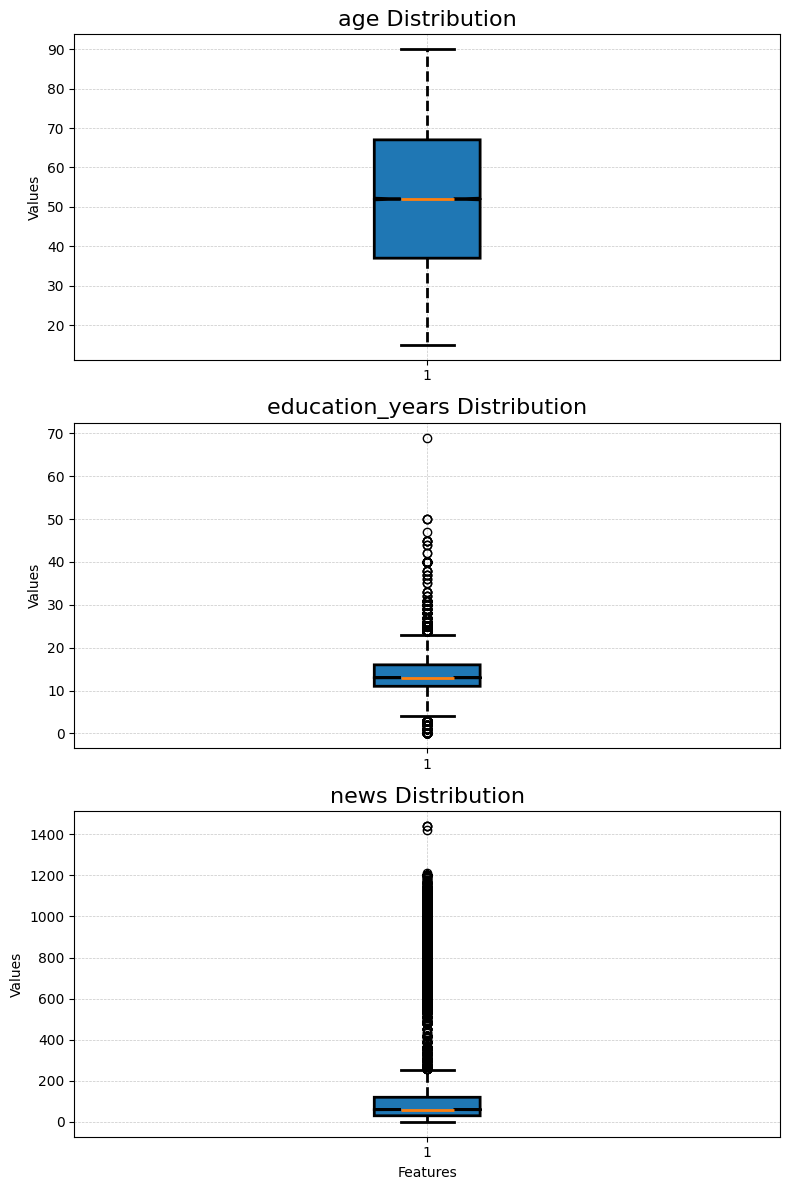

In [9]:
box_cols = ['age', 'education_years', 'news']

# Convert to numeric + drop missing values
box_data = X[box_cols].apply(pd.to_numeric, errors='coerce').dropna()

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

boxprops = dict(linestyle='-', linewidth=2)
medianprops = dict(linestyle='-', linewidth=2)
whiskerprops = dict(linestyle='--', linewidth=2)
capprops = dict(linestyle='-', linewidth=2)

for i, col in enumerate(box_cols):
    axes[i].boxplot(
        box_data[col].values,
        notch=True,
        patch_artist=True,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops
    )

    axes[i].set_title(f'{col} Distribution', fontsize=16)
    axes[i].set_ylabel('Values')
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

axes[-1].set_xlabel('Features')

plt.tight_layout()
plt.show()
#plt.savefig('Age_Eduyrs_boxplot.pdf', dpi=300)



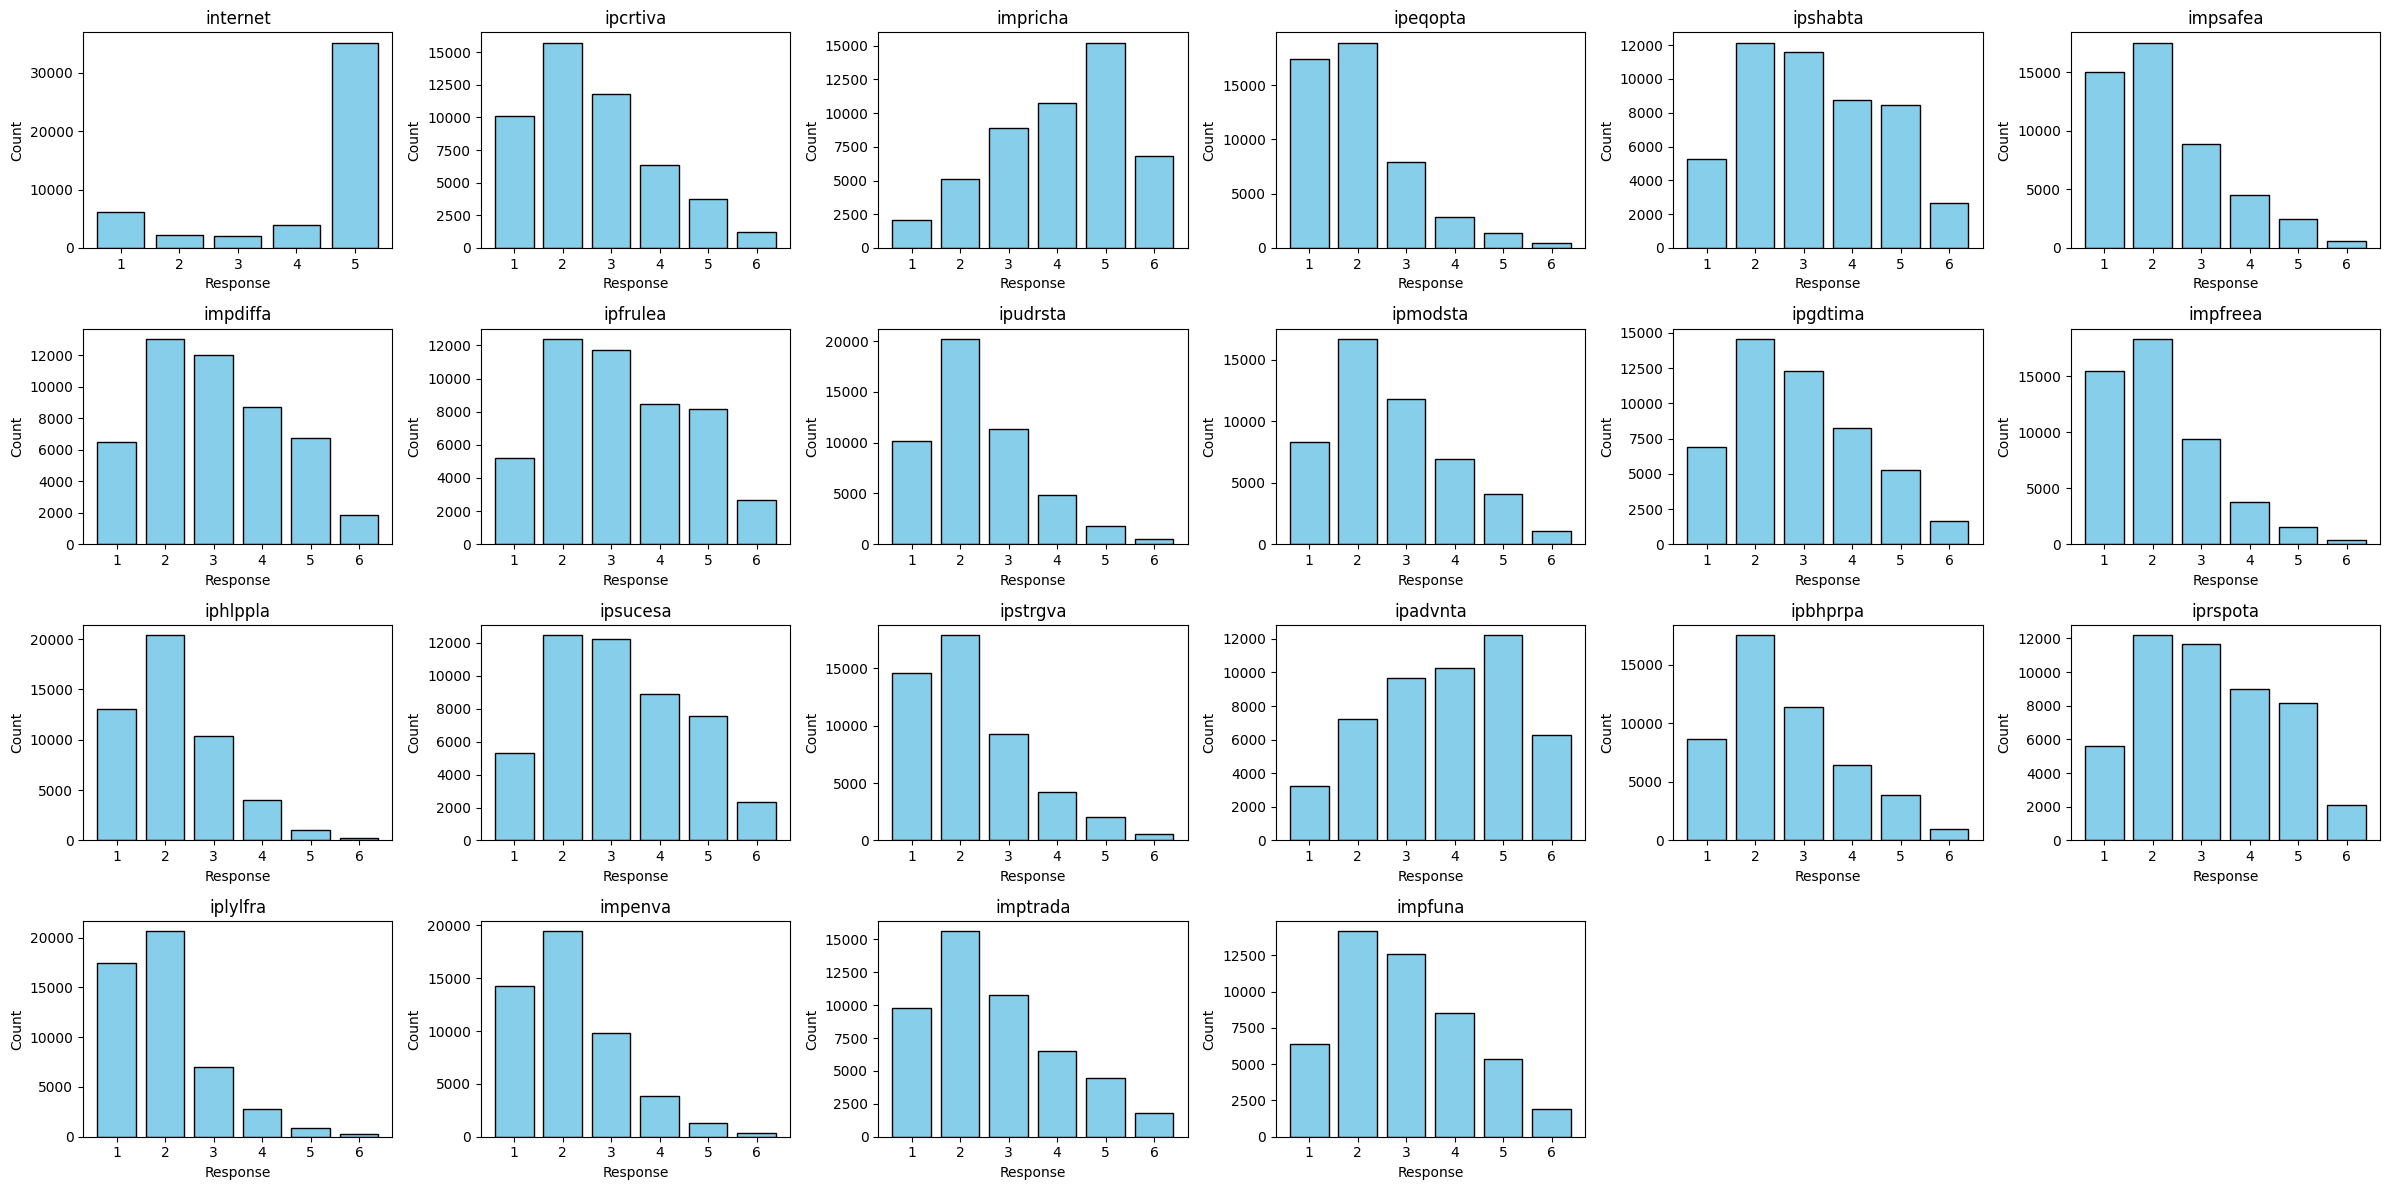

In [10]:



likert_cols = [c for c in numerical_cols if c not in ['age', 'education_years', 'news']]

n_cols = 6
n_rows = int(np.ceil(len(likert_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(24, 12))
ax = ax.flatten()

for i, column in enumerate(likert_cols):
    counts = X[column].value_counts().sort_index()
    
    # Plot bar chart
    ax[i].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
    
    # Titles and labels
    ax[i].set_title(column)
    ax[i].set_xlabel('Response')
    ax[i].set_ylabel('Count')
    
    # Dynamically set x-ticks based on actual responses
    ax[i].set_xticks(counts.index)
    
# Delete any extra empty axes
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()
# Optional: save figure
# plt.savefig('Likert_item_counts.pdf', dpi=300)

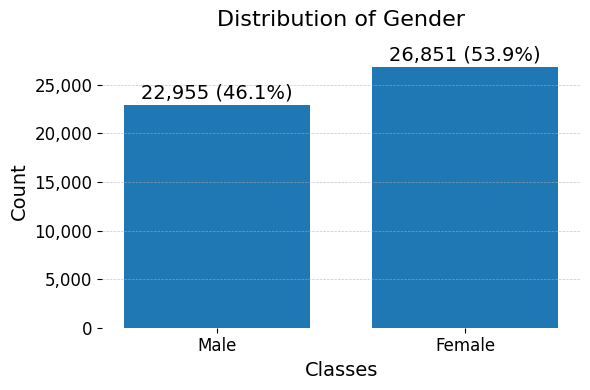

In [11]:
# Count samples in each class (bctprd = 1 or 2)
class_counts = [
    np.sum(df_clean['gender'] == 1),
    np.sum(df_clean['gender'] == 2)
]

class_labels = ['Male', 'Female']

# Calculate percentages
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Title and labels
plt.title('Distribution of Gender', fontsize=16, pad=20)  # space above bars
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels above the bars with count and percentage
for bar, percent in zip(bars, class_percents):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(class_counts)*0.01,  # slightly above the bar
        f"{int(yval):,} ({percent:.1f}%)",  # count with thousands separator and %
        ha='center',
        va='bottom',
        fontsize=14
    )

# Format y-axis with thousands separator
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('gender_class_dist.pdf', dpi=300)
plt.show()


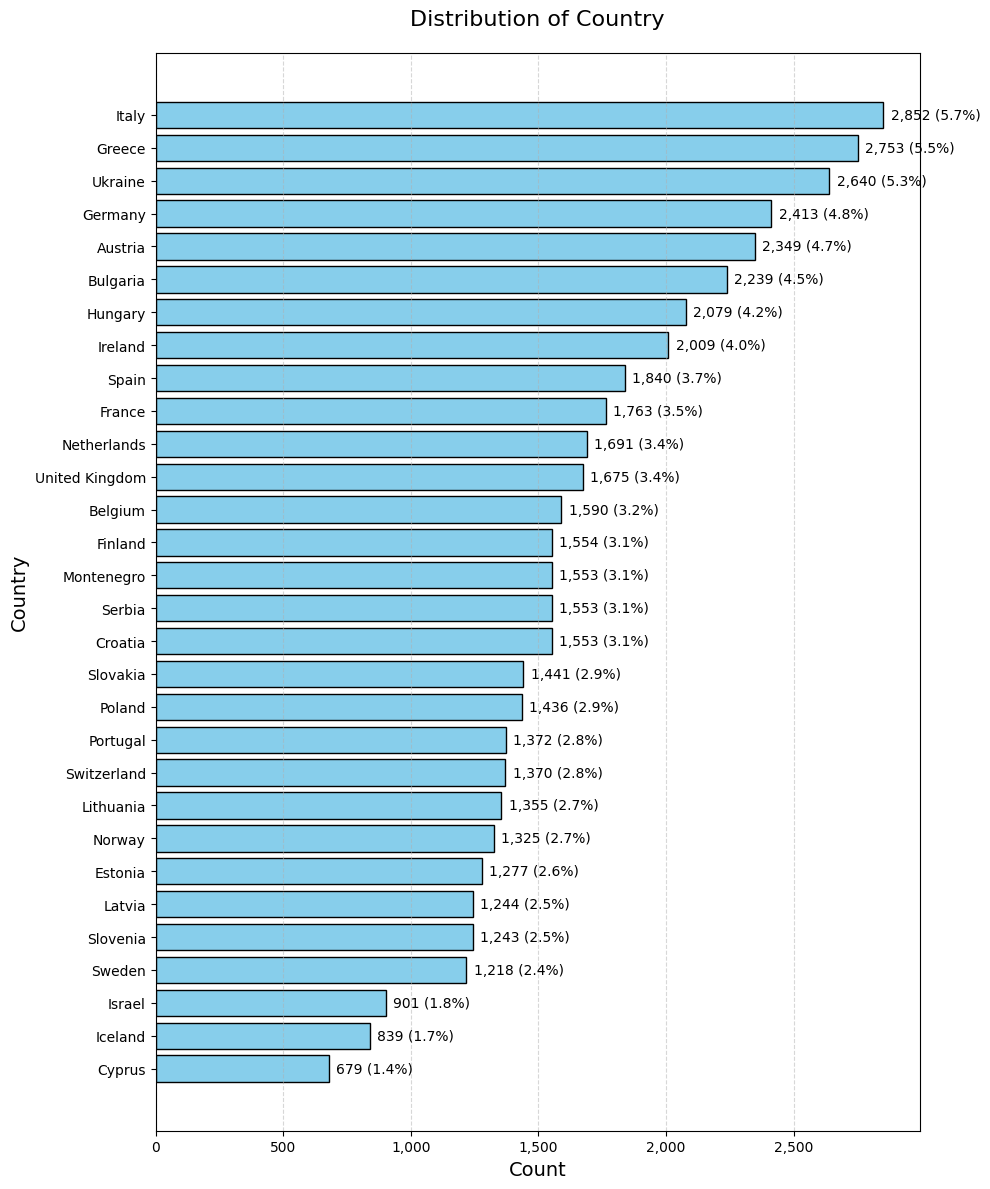

In [12]:


# List of country codes and labels
countries = [
    'AT','BE','BG','CH','CY','DE','EE','ES','FI','FR','GB','GR','HR',
    'HU','IE','IS','IL','IT','LT','LV','ME','NL','NO','PL','PT','RS',
    'SE','SI','SK','UA'
]

country_labels = [
    'Austria','Belgium','Bulgaria','Switzerland','Cyprus','Germany',
    'Estonia','Spain','Finland','France','United Kingdom','Greece','Croatia','Hungary',
    'Ireland','Iceland','Israel','Italy','Lithuania','Latvia','Montenegro','Netherlands',
    'Norway','Poland','Portugal','Serbia',
    'Sweden','Slovenia','Slovakia','Ukraine'
]

# Compute counts
class_counts = [np.sum(df_clean['country'] == c) for c in countries]
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Sort from lowest to highest
sorted_idx = np.argsort(class_counts)
sorted_counts = [class_counts[i] for i in sorted_idx]
sorted_labels = [country_labels[i] for i in sorted_idx]
sorted_percents = [class_percents[i] for i in sorted_idx]

# Horizontal bar plot
plt.figure(figsize=(10, 12))
bars = plt.barh(sorted_labels, sorted_counts, color='skyblue', edgecolor='black')

plt.xlabel('Count', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.title('Distribution of Country', fontsize=16, pad=20)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# Add value labels with count and percentage
for bar, percent in zip(bars, sorted_percents):
    width = bar.get_width()
    plt.text(
        width + max(sorted_counts)*0.01,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,} ({percent:.1f}%)",
        va='center',
        fontsize=10
    )

# Format x-axis with thousands separator
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
#plt.savefig('country_class_dist_horizontal.pdf', dpi=300)
plt.show()


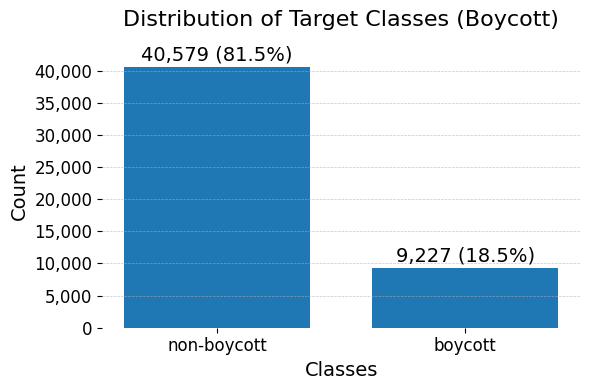

In [13]:
# Count samples in each class (bctprd = 1 or 2)
class_counts = [
    np.sum(df_clean['boycott'] == 0),
    np.sum(df_clean['boycott'] == 1)
]

class_labels = ['non-boycott', 'boycott']

# Calculate percentages
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Title and labels
plt.title('Distribution of Target Classes (Boycott)', fontsize=16, pad=20)  # space above bars
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels above the bars with count and percentage
for bar, percent in zip(bars, class_percents):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(class_counts)*0.01,  # slightly above the bar
        f"{int(yval):,} ({percent:.1f}%)",  # count with thousands separator and %
        ha='center',
        va='bottom',
        fontsize=14
    )

# Format y-axis with thousands separator
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('bctprd_class_dist.pdf', dpi=300)
plt.show()


In [14]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Figure size 2000x600 with 0 Axes>

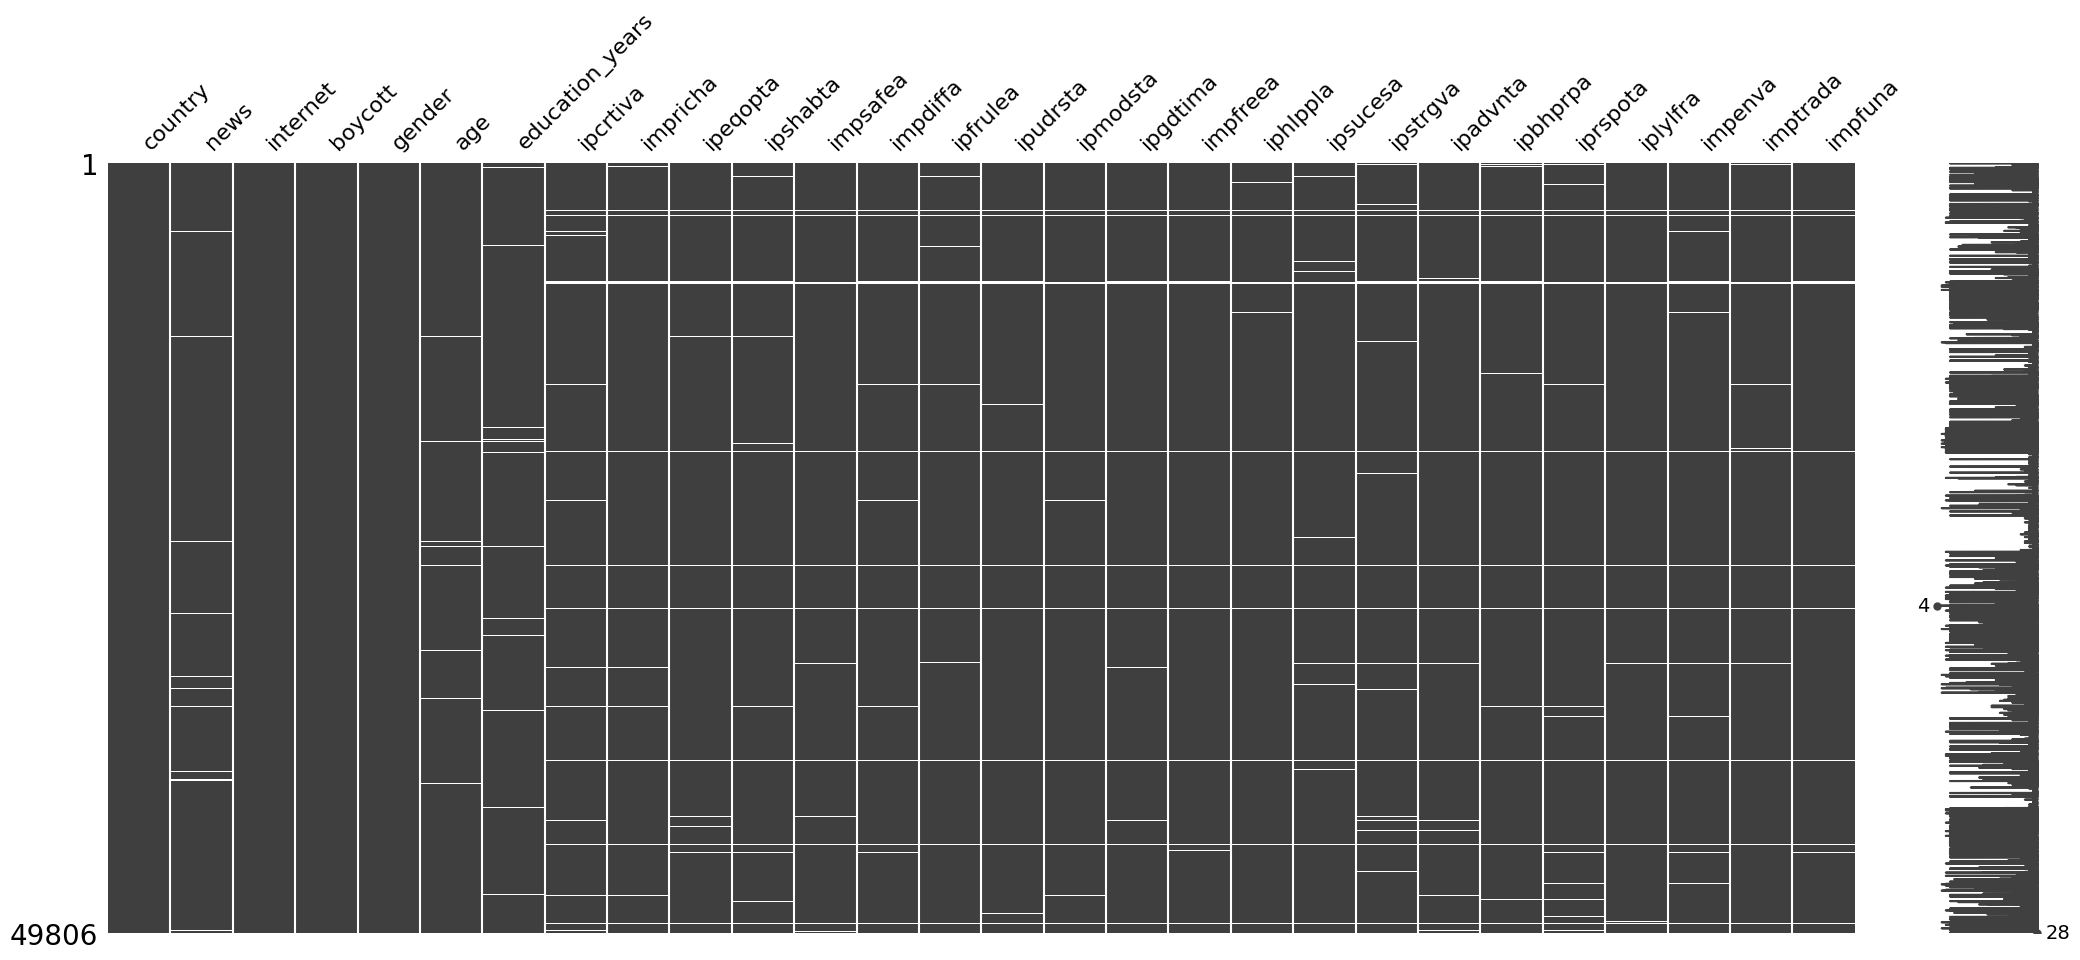

<Figure size 1200x1000 with 0 Axes>

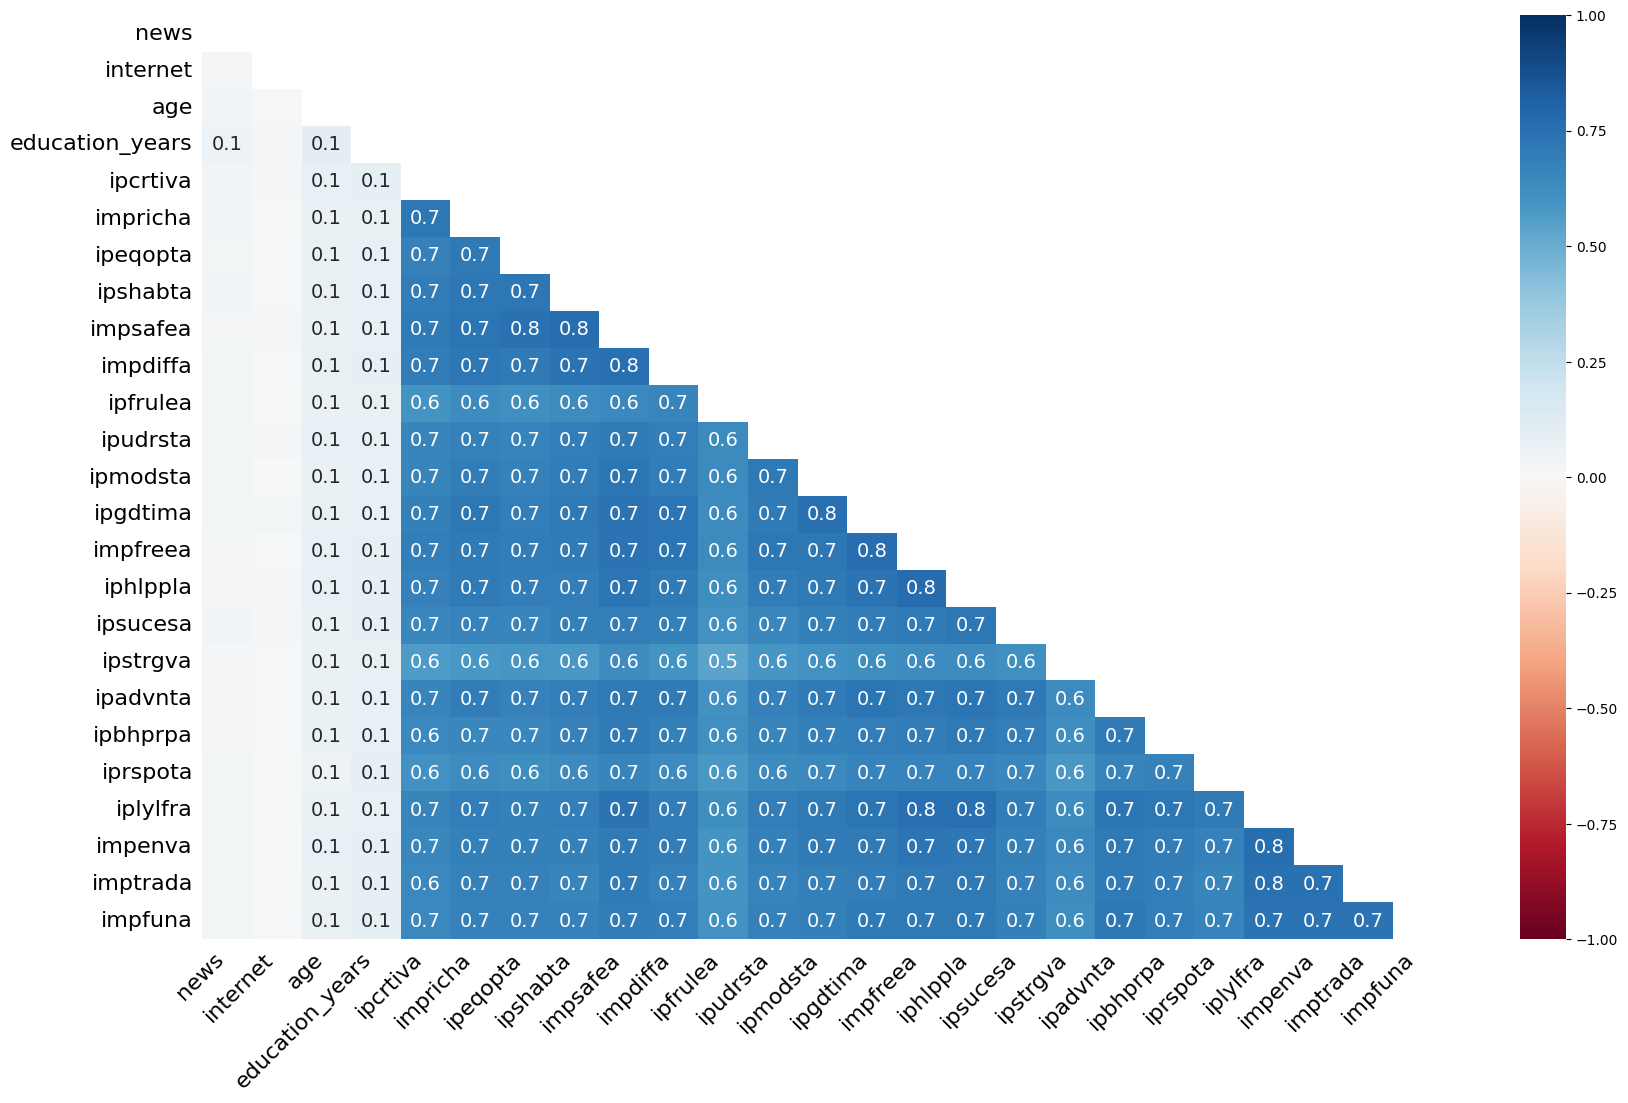

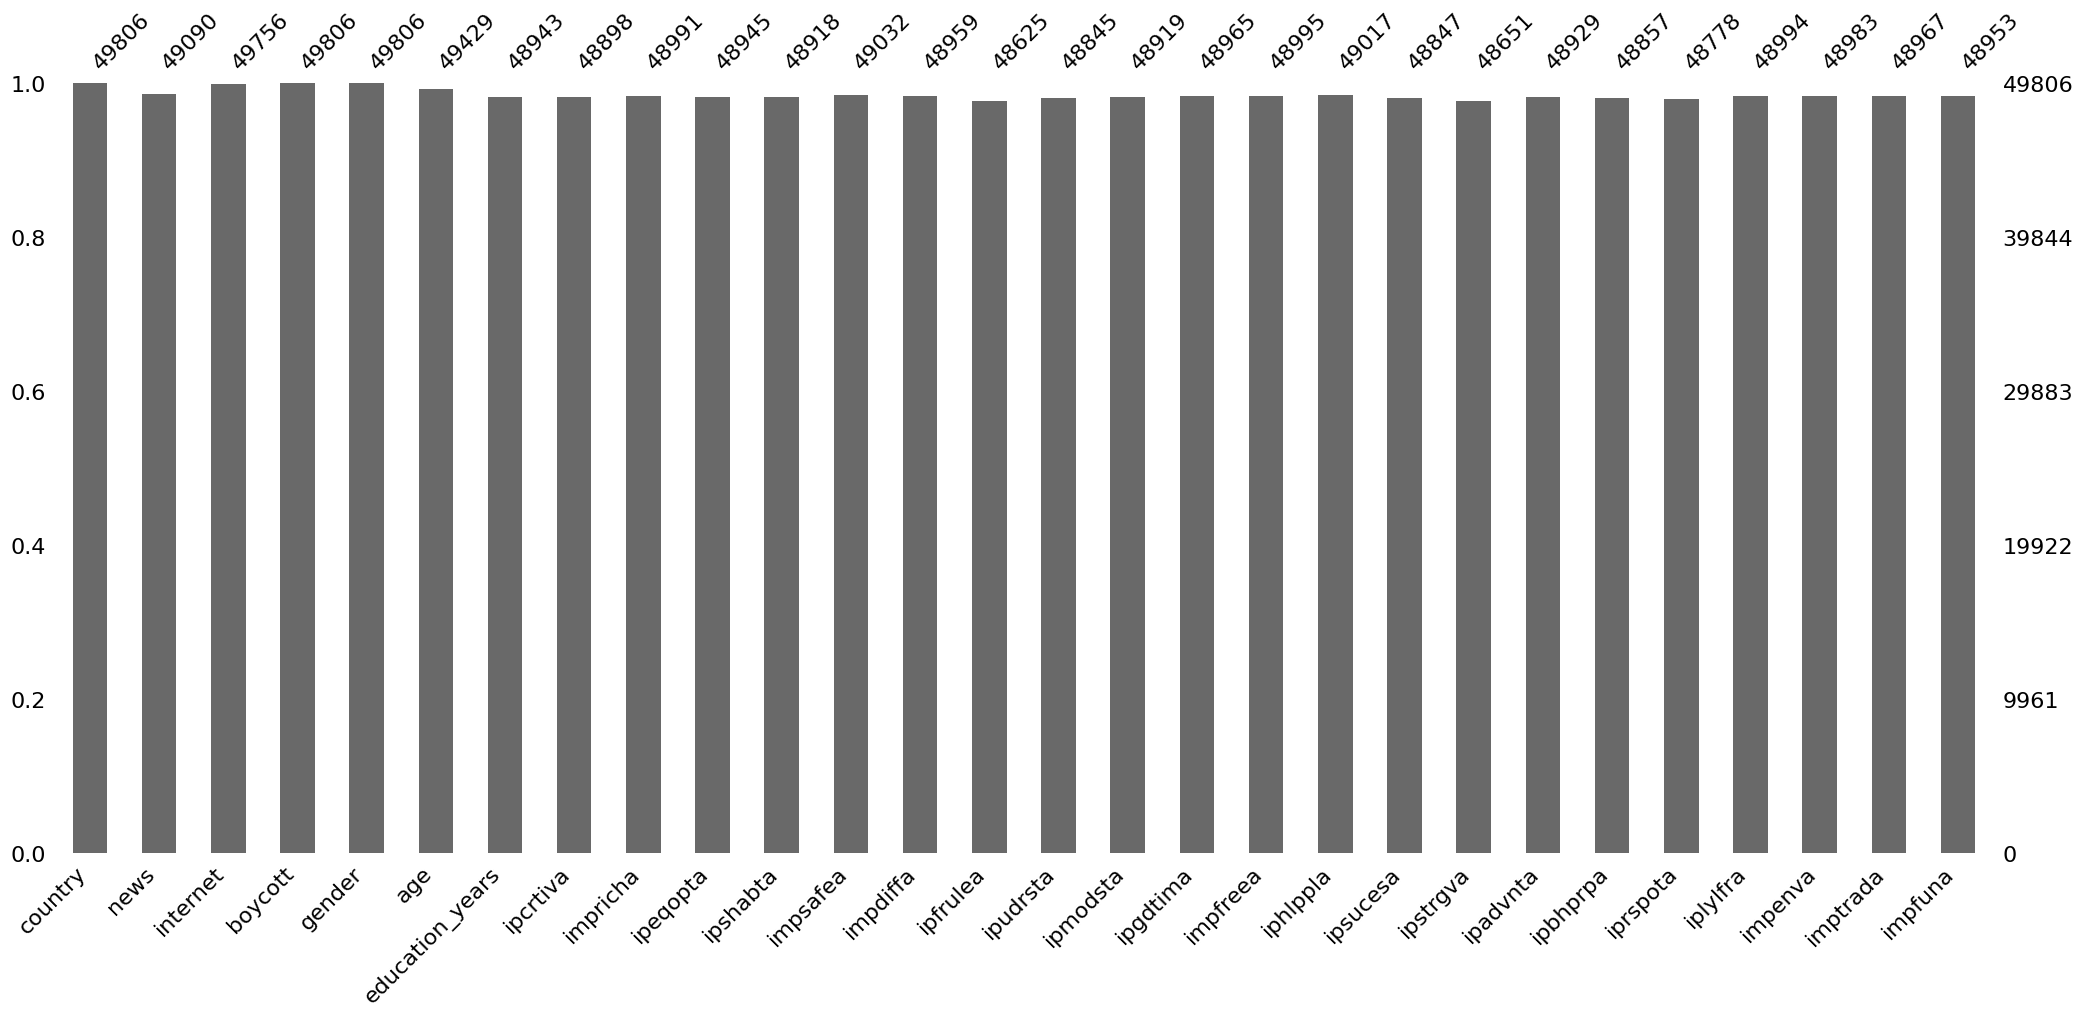

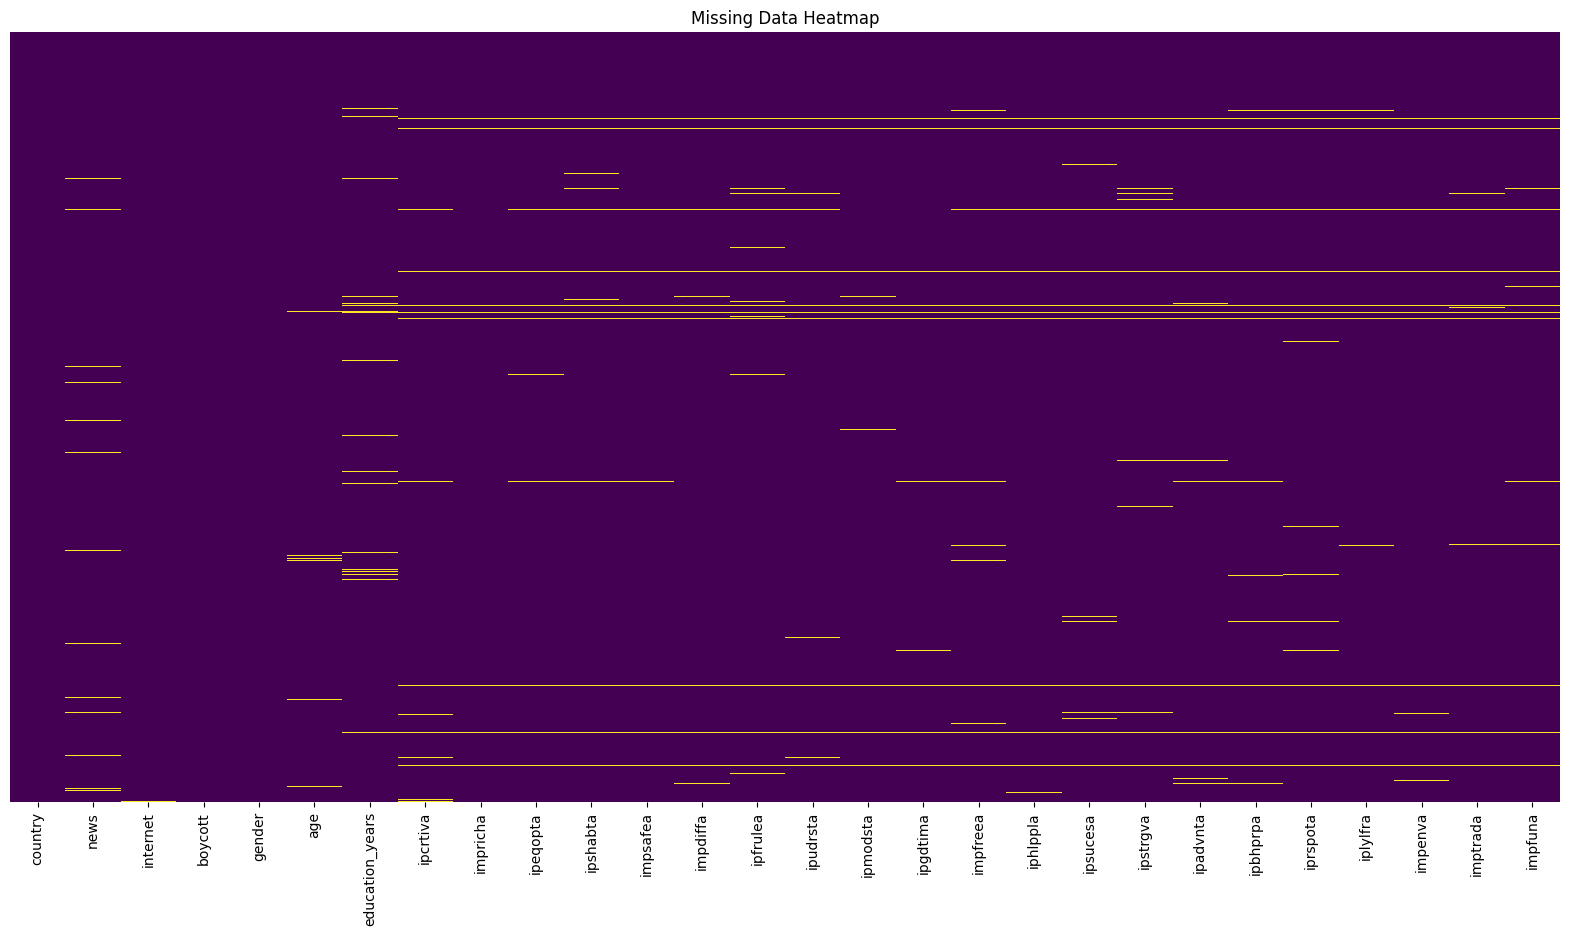

Missing values (%) per column:
ipfrulea           2.371200
ipstrgva           2.318998
iprspota           2.064008
ipudrsta           1.929486
ipsucesa           1.925471
ipbhprpa           1.905393
ipcrtiva           1.823074
ipshabta           1.782918
ipmodsta           1.780910
ipadvnta           1.760832
education_years    1.732723
ipeqopta           1.728707
impfuna            1.712645
impdiffa           1.700598
ipgdtima           1.688552
imptrada           1.684536
impenva            1.652411
impricha           1.636349
iplylfra           1.630326
impfreea           1.628318
iphlppla           1.584146
impsafea           1.554030
news               1.437578
age                0.756937
internet           0.100390
gender             0.000000
country            0.000000
boycott            0.000000
dtype: float64


In [15]:
#missing data pattern
import missingno as msno

# 8a. Missing data matrix
plt.figure(figsize=(20,6))
msno.matrix(df_clean)
plt.show()

# 8b. Missing data heatmap (shows correlation of missingness)
plt.figure(figsize=(12,10))
msno.heatmap(df_clean)
plt.show()

# 8c. Missing data bar chart (count per column)
plt.figure(figsize=(16,6))
msno.bar(df_clean)
plt.show()

# 8d. Optional: seaborn heatmap for full matrix view
plt.figure(figsize=(20,10))
sns.heatmap(df_clean.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# 9️⃣ OPTIONAL: check missing percentage numerically
missing_percent = df_clean.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print("Missing values (%) per column:")
print(missing_percent)




## 1.4 Preprocessing

In [16]:
#remove outlier
data = df_clean['news']

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outlier_percentage = (
    ((data < (Q1 - 1.5*IQR)) | (data > (Q3 + 1.5*IQR))).sum()
    / len(data) * 100
)

print(outlier_percentage)


#calculate 99% percentile
upper_99 = df_clean['news'].quantile(0.99)
print("99th percentile (upper limit):", upper_99)

# remove outliers
df_clean = df_clean[df_clean['news'] <= upper_99]

# sense check max
max_value_after_clean = df_clean['news'].max()
remaining_samples = df_clean.shape[0]

print("Max value after removing extreme values:", max_value_after_clean)
print("Number of remaining samples:", remaining_samples)
print(outlier_percentage)

5.854716299241056
99th percentile (upper limit): 941.3300000000017
Max value after removing extreme values: 941.0
Number of remaining samples: 48599
5.854716299241056


In [17]:
before_rows = df_clean.shape[0]

# delete rows over 40% missing values
threshold = int(df_clean.shape[1] * 0.6)
df_clean = df_clean.dropna(thresh=threshold)

after_rows = df_clean.shape[0]
print("Rows before removal:", before_rows)
print("Rows after removal:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removal: 48599
Rows after removal: 48020
Rows removed: 579


In [18]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 48020 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          48020 non-null  str    
 1   news             48020 non-null  float64
 2   internet         47977 non-null  float64
 3   boycott          48020 non-null  object 
 4   gender           48020 non-null  object 
 5   age              47701 non-null  float64
 6   education_years  47292 non-null  float64
 7   ipcrtiva         47703 non-null  float64
 8   impricha         47787 non-null  float64
 9   ipeqopta         47739 non-null  float64
 10  ipshabta         47728 non-null  float64
 11  impsafea         47829 non-null  float64
 12  impdiffa         47762 non-null  float64
 13  ipfrulea         47453 non-null  float64
 14  ipudrsta         47670 non-null  float64
 15  ipmodsta         47745 non-null  float64
 16  ipgdtima         47789 non-null  float64
 17  impfreea         47810 non-n

In [19]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 48020 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          48020 non-null  str    
 1   news             48020 non-null  float64
 2   internet         47977 non-null  float64
 3   boycott          48020 non-null  object 
 4   gender           48020 non-null  object 
 5   age              47701 non-null  float64
 6   education_years  47292 non-null  float64
 7   ipcrtiva         47703 non-null  float64
 8   impricha         47787 non-null  float64
 9   ipeqopta         47739 non-null  float64
 10  ipshabta         47728 non-null  float64
 11  impsafea         47829 non-null  float64
 12  impdiffa         47762 non-null  float64
 13  ipfrulea         47453 non-null  float64
 14  ipudrsta         47670 non-null  float64
 15  ipmodsta         47745 non-null  float64
 16  ipgdtima         47789 non-null  float64
 17  impfreea         47810 non-n

In [20]:
df_clean.describe()

,news,internet,age,education_years,ipcrtiva,impricha,ipeqopta,ipshabta,impsafea,impdiffa,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
count,48020.000000,47977.000000,47701.000000,47292.000000,47703.000000,47787.000000,47739.000000,47728.000000,47829.000000,47762.000000,...,47819.000000,47681.000000,47466.000000,47749.000000,47679.000000,47613.000000,47802.000000,47786.000000,47771.000000,47763.000000
mean,88.078176,4.209455,51.638917,13.269644,2.617907,4.076046,2.043801,3.225318,2.256539,3.035886,...,2.190405,3.168579,2.243142,3.813064,2.633717,3.168609,1.968307,2.171117,2.709405,2.957038
std,127.151362,1.413080,18.604767,4.021168,1.289672,1.359482,1.072544,1.411892,1.194954,1.366847,...,1.020425,1.378260,1.166484,1.456293,1.248895,1.386924,0.977723,1.057693,1.364737,1.331004
min,0.000000,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,30.000000,4.000000,37.000000,11.000000,2.000000,3.000000,1.000000,2.000000,1.000000,2.000000,...,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000
50%,60.000000,5.000000,52.000000,13.000000,2.000000,4.000000,2.000000,3.000000,2.000000,3.000000,...,2.000000,3.000000,2.000000,4.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000
75%,105.000000,5.000000,67.000000,16.000000,3.000000,5.000000,3.000000,4.000000,3.000000,4.000000,...,3.000000,4.000000,3.000000,5.000000,3.000000,4.000000,2.000000,3.000000,4.000000,4.000000
max,941.000000,5.000000,90.000000,69.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000


# ALL using simpler

In [21]:
pip install xgboost catboost

Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Random Classifier

In [23]:
import numpy as np
np.random.seed(42)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_recall_curve, auc, precision_score, recall_score
from sklearn.impute import SimpleImputer

X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {"model__strategy": ["stratified", "most_frequent"]}

outer_f1, outer_pr_auc, outer_precision, outer_recall = [], [], [], []

for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(random_state=42))
    ])

    grid = GridSearchCV(pipeline, param_grid=param_grid, cv=inner_cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    outer_f1.append(f1_score(y_test, y_pred, zero_division=0))
    outer_precision.append(precision_score(y_test, y_pred, zero_division=0))
    outer_recall.append(recall_score(y_test, y_pred, zero_division=0))

    p, r, _ = precision_recall_curve(y_test, y_prob)
    outer_pr_auc.append(auc(r, p))

print("Random Baseline")
print(f"F1:        {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
print(f"PR-AUC:    {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
print(f"Recall:    {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")

/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_58842/3837461802.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


Random Baseline
F1:        0.181 ± 0.004
PR-AUC:    0.257 ± 0.003
Precision: 0.184 ± 0.004
Recall:    0.178 ± 0.004


In [24]:
conda install -c conda-forge llvm-openmp

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [38]:
import numpy as np
import pandas as pd
from itertools import product
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, average_precision_score, precision_score, recall_score

# Model Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# -----------------------------
# 1. Data Setup
# -----------------------------
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns
X[categorical_cols] = X[categorical_cols].astype(str)

cat_indices = list(range(len(numerical_cols), len(numerical_cols) + len(categorical_cols)))

# -----------------------------
# 2. Preprocessors
# -----------------------------
preprocessor_standard = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

preprocessor_scaled = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

preprocessor_native = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numerical_cols),
    ('cat', 'passthrough', categorical_cols)
])

# -----------------------------
# 3a. Sklearn Models (LR, RF, XGB)
# -----------------------------
def run_nested_cv_sklearn(X, y, use_class_weight=False):
    random_state = 42
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    scale_factor = (y == 0).sum() / (y == 1).sum()

    model_specs = {
        "Logistic Regression": {
            "model": LogisticRegression(max_iter=2000, solver='liblinear',
                                        class_weight='balanced' if use_class_weight else None),
            "params": {"model__C": [0.1, 1.0, 10.0]},
            "prep": preprocessor_scaled,
        },
        "Random Forest": {
            "model": RandomForestClassifier(random_state=random_state,
                                            class_weight='balanced' if use_class_weight else None),
            "params": {"model__n_estimators": [50, 100, 200], "model__max_depth": [None, 5, 10]},
            "prep": preprocessor_standard,
        },
        "XGBoost": {
            "model": XGBClassifier(eval_metric='logloss', random_state=random_state,
                                   scale_pos_weight=scale_factor if use_class_weight else 1),
            "params": {"model__n_estimators": [50, 100, 200], "model__max_depth": [3, 6, 10], "model__learning_rate": [0.1, 0.3, 0.5]},
            "prep": preprocessor_standard,
        }
    }

    results = {}
    for name, spec in model_specs.items():
        print(f"Running {name}...")
        fold_f1, fold_pr_auc, fold_prec, fold_rec = [], [], [], []

        for train_idx, test_idx in outer_cv.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            pipeline = Pipeline([
                ("preprocessor", spec["prep"]),
                ("model", spec["model"])
            ])

            grid_search = GridSearchCV(pipeline, spec["params"], cv=inner_cv, scoring='f1', n_jobs=-1)
            grid_search.fit(X_train, y_train)

            best_model = grid_search.best_estimator_
            y_pred = best_model.predict(X_test)
            y_prob = best_model.predict_proba(X_test)[:, 1]

            fold_f1.append(f1_score(y_test, y_pred))
            fold_pr_auc.append(average_precision_score(y_test, y_prob))
            fold_prec.append(precision_score(y_test, y_pred, zero_division=0))
            fold_rec.append(recall_score(y_test, y_pred))

        results[name] = {
            'test_f1': fold_f1,
            'test_average_precision': fold_pr_auc,
            'test_precision': fold_prec,
            'test_recall': fold_rec
        }

    return results


# -----------------------------
# 3b. CatBoost (manual grid search to avoid clone issues)
# -----------------------------
def run_nested_cv_catboost(X, y, use_class_weight=False):
    random_state = 42
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    param_grid = {
        'iterations': [500, 1000, 2000],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.03, 0.1]
    }

    fold_f1, fold_pr_auc, fold_prec, fold_rec = [], [], [], []

    print("Running CatBoost...")

    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Impute numericals manually (CatBoost handles cats natively)
        num_imputer = SimpleImputer(strategy='median')
        X_train_num = num_imputer.fit_transform(X_train[numerical_cols])
        X_test_num = num_imputer.transform(X_test[numerical_cols])

        X_train_proc = np.hstack([X_train_num, X_train[categorical_cols].values])
        X_test_proc = np.hstack([X_test_num, X_test[categorical_cols].values])

        # Manual inner CV grid search
        best_score = -1
        best_params = None

        for iterations, depth, lr in product(param_grid['iterations'], param_grid['depth'], param_grid['learning_rate']):
            inner_scores = []
            for inner_train_idx, inner_val_idx in inner_cv.split(X_train_proc, y_train):
                Xi_train, Xi_val = X_train_proc[inner_train_idx], X_train_proc[inner_val_idx]
                yi_train, yi_val = y_train.iloc[inner_train_idx], y_train.iloc[inner_val_idx]

                model = CatBoostClassifier(
                    verbose=0,
                    random_state=random_state,
                    allow_writing_files=False,
                    cat_features=cat_indices,
                    auto_class_weights='Balanced' if use_class_weight else None,
                    iterations=iterations,
                    depth=depth,
                    learning_rate=lr
                )
                model.fit(Xi_train, yi_train)
                y_pred_inner = model.predict(Xi_val)
                inner_scores.append(f1_score(yi_val, y_pred_inner))

            mean_score = np.mean(inner_scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'iterations': iterations, 'depth': depth, 'learning_rate': lr}

        # Refit best model on full outer train
        best_model = CatBoostClassifier(
            verbose=0,
            random_state=random_state,
            allow_writing_files=False,
            cat_features=cat_indices,
            auto_class_weights='Balanced' if use_class_weight else None,
            **best_params
        )
        best_model.fit(X_train_proc, y_train)

        y_pred = best_model.predict(X_test_proc)
        y_prob = best_model.predict_proba(X_test_proc)[:, 1]

        fold_f1.append(f1_score(y_test, y_pred))
        fold_pr_auc.append(average_precision_score(y_test, y_prob))
        fold_prec.append(precision_score(y_test, y_pred, zero_division=0))
        fold_rec.append(recall_score(y_test, y_pred))

    return {
        "CatBoost": {
            'test_f1': fold_f1,
            'test_average_precision': fold_pr_auc,
            'test_precision': fold_prec,
            'test_recall': fold_rec
        }
    }


# -----------------------------
# 4. RUN AND PRINT
# -----------------------------
res_weighted = {**run_nested_cv_catboost(X, y, use_class_weight=True),
                **run_nested_cv_sklearn(X, y, use_class_weight=True)}

res_unweighted = {**run_nested_cv_catboost(X, y, use_class_weight=False),
                  **run_nested_cv_sklearn(X, y, use_class_weight=False)}

for label, res_dict in [("WITH weighting", res_weighted), ("WITHOUT weighting", res_unweighted)]:
    print(f"\n--- RESULTS {label} ---")
    for name, stats in res_dict.items():
        print(f"\n{name} {label}")
        print(f"  F1: {np.mean(stats['test_f1']):.3f} ± {np.std(stats['test_f1']):.3f}")
        print(f"  PR-AUC: {np.mean(stats['test_average_precision']):.3f} ± {np.std(stats['test_average_precision']):.3f}")
        print(f"  Precision: {np.mean(stats['test_precision']):.3f} ± {np.std(stats['test_precision']):.3f}")
        print(f"  Recall: {np.mean(stats['test_recall']):.3f} ± {np.std(stats['test_recall']):.3f}")

/var/folders/p5/dd0mn9h16750wt2b1yj0qkf80000gn/T/ipykernel_58842/3656542672.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


Running CatBoost...


KeyboardInterrupt: 

In [ ]:
# -----------------------------
# 5. PLOT (Weighted Only)
# -----------------------------
current_results = res_weighted 
models_to_plot = list(current_results.keys())
metrics_map = {
    'F1-score': 'test_f1',
    'PR-AUC': 'test_average_precision', 
    'Precision': 'test_precision',
    'Recall': 'test_recall'
}

means = {m: [np.mean(current_results[model][key]) for model in models_to_plot] for m, key in metrics_map.items()}
stds = {m: [np.std(current_results[model][key]) for model in models_to_plot] for m, key in metrics_map.items()}

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models_to_plot)))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (metric_name, _) in enumerate(metrics_map.items()):
    ax = axes[i]
    bars = ax.bar(models_to_plot, means[metric_name], yerr=stds[metric_name], capsize=6, color=colors, alpha=0.85)
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    for spine in ax.spines.values(): 
        spine.set_visible(False)
    
    for bar, mean in zip(bars, means[metric_name]):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.02, f"{mean:.3f}", 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

fig.suptitle('Comparison of Classifier Performance (WITH Class Weighting)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
np.random.seed(42)

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, precision_recall_curve, auc,
    precision_score, recall_score, confusion_matrix
)

from catboost import CatBoostClassifier
from sklearn.impute import SimpleImputer

# -----------------------------
# Data
# -----------------------------
X = df_clean.drop('boycott', axis=1)
y = df_clean['boycott'].astype(int)

numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

X[categorical_cols] = X[categorical_cols].astype(str)
cat_features = [X.columns.get_loc(col) for col in categorical_cols]

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------------
# Imputation
# -----------------------------
imputer = SimpleImputer(strategy='median')
X_train[numerical_cols] = imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = imputer.transform(X_test[numerical_cols])

# -----------------------------
# Param grid (UNCHANGED)
# -----------------------------
param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.1]
}

# -----------------------------
# CV setup
# -----------------------------
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Function
# -----------------------------
def run_catboost_full(X_train, y_train, X_test, y_test, use_class_weight=False, threshold=0.5):

    print(f"\nCatBoost {'WITH' if use_class_weight else 'WITHOUT'} weighting")

    # class weights
    if use_class_weight:
        n_neg = (y_train == 0).sum()
        n_pos = (y_train == 1).sum()
        class_weights = [1, n_neg / n_pos]
    else:
        class_weights = None

    outer_f1, outer_pr_auc, outer_precision, outer_recall = [], [], [], []

    # -----------------------------
    # 1. CV on TRAIN (mean ± std)
    # -----------------------------
    for train_idx, val_idx in outer_cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(
            verbose=0,
            random_state=42,
            class_weights=class_weights
        )

        grid = GridSearchCV(
            model,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='f1',
            n_jobs=-1
        )

        grid.fit(X_tr, y_tr, cat_features=cat_features)
        best_model = grid.best_estimator_

        y_prob = best_model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        outer_f1.append(f1_score(y_val, y_pred))
        outer_precision.append(precision_score(y_val, y_pred, zero_division=0))
        outer_recall.append(recall_score(y_val, y_pred))

        p, r, _ = precision_recall_curve(y_val, y_prob)
        outer_pr_auc.append(auc(r, p))

    print("\n--- CV (Train 80%) ---")
    print(f"F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
    print(f"PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")
    print(f"Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
    print(f"Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")

    # -----------------------------
    # 2. Train final model on FULL 80%
    # -----------------------------
    final_model = CatBoostClassifier(
        verbose=0,
        random_state=42,
        class_weights=class_weights
    )

    final_grid = GridSearchCV(
        final_model,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='f1',
        n_jobs=-1
    )

    final_grid.fit(X_train, y_train, cat_features=cat_features)
    best_final_model = final_grid.best_estimator_

    # -----------------------------
    # 3. Evaluate on HOLDOUT (20%)
    # -----------------------------
    y_prob = best_final_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)

    p, r, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(r, p)

    print("\n--- HOLDOUT (20%) ---")
    print(f"F1: {f1:.3f}")
    print(f"PR-AUC: {pr_auc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")

    # -----------------------------
    # 4. Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

In [ ]:
run_catboost_full(X_train, y_train, X_test, y_test, use_class_weight=False)
run_catboost_full(X_train, y_train, X_test, y_test, use_class_weight=True)


CatBoost WITHOUT weighting

--- CV (Train 80%) ---
F1: 0.380 ± 0.007
PR-AUC: 0.497 ± 0.006
Precision: 0.637 ± 0.014
Recall: 0.271 ± 0.007

--- HOLDOUT (20%) ---
F1: 0.387
PR-AUC: 0.501
Precision: 0.625
Recall: 0.280

Confusion Matrix:
[[7519  300]
 [1285  500]]

CatBoost WITH weighting

--- CV (Train 80%) ---
F1: 0.502 ± 0.012
PR-AUC: 0.498 ± 0.010
Precision: 0.413 ± 0.012
Recall: 0.641 ± 0.011

--- HOLDOUT (20%) ---
F1: 0.500
PR-AUC: 0.511
Precision: 0.404
Recall: 0.658

Confusion Matrix:
[[6083 1736]
 [ 610 1175]]
